<a href="https://colab.research.google.com/github/mayashah100/MEI-Data-Science-Project/blob/main/MEI_DataScienceCourse_Lesson6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

The problem in this activity is an introduction to a different type of *machine learning* from the one you met in lesson 5. In it you will explore how you can predict whether data should be classified into one of two groups based on the values of other features in a dataset. Classifying data into two groups is known as **binary classification**.

The data for this activity comes from a study of three different species of Antartic penguin: Adelie, Chinstrap and Gentoo. The data was observed on the islands of the Palmer Archipelago, Antarctica between 2007 and 2009. There are 344 individual records, each representing a single penguin.

## Problem

***Can the species of a penguin be predicted using different body measurements?***

To answer this question you could find statistics and create charts comparing the numerical features recorded for the different species of penguins in the dataset. You can then build a model that predicts the species of penguin based on the numerical features.

## Importing libraries and data

> Run the code boxes below to import the libraries and the data.

# MEI Introduction to Data Science: Lesson 6 - Activity 1


In [ ]:
# import pandas and seaborn
import pandas as pd
import seaborn as sns

# import modelling functions for decision trees from sklearn
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# import pyplot from matplotlib for displaying decision trees
import matplotlib.pyplot as plt

In [ ]:
# create a plot_decision_tree command for displaying the decision tree
def plot_decision_tree(model):
    fig, ax = plt.subplots(figsize=(14,8))
    plot_tree(model, filled=True, impurity=False, label='root', feature_names=input_features, proportion=True,
              class_names=["No", "Yes"], ax=ax)
    plt.show()

In [ ]:
# import the data to your Google Drive - data is at https://drive.google.com/file/d/11jWQyIYQyqSC3XxJm18-yxcpTHE5Ddjg/view?usp=sharing
!gdown '11jWQyIYQyqSC3XxJm18-yxcpTHE5Ddjg'

# import the data - the .dropna() function removes any rows with missing data
penguin_data = pd.read_csv('/content/penguins.csv')

# display the data to check it has imported
penguin_data

Downloading...
From: https://drive.google.com/uc?id=11jWQyIYQyqSC3XxJm18-yxcpTHE5Ddjg
To: /content/penguins.csv
100% 19.6k/19.6k [00:00<00:00, 24.9MB/s]


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


This data set contains information about penguins observed on the islands of the Palmer Archipelago, Antarctica between 2007 and 2009.
Features:
* **Species**: *Adélie, Chinstrap or Gentoo*
* **Island**: *Where the penguin was observed (Biscoe, Dream or Torgersen)*
* **bill_length_mm**: *Bill length (mm)*
* **bill_depth_mm**: *Bill depth (mm)*
* **flipper_length_mm**: *Flipper length (mm)*
* **body_mass_g**: *Body mass (g)*
* **sex**: *male or female*
* **year**: *2007, 2008 or 2009*

> Run the code below to explore the data types for the features.

In [ ]:
# display the data types
penguin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


## Pre-processing
## Removing incomplete rows and adding a binary feature

Some of the rows are incomplete. You can see this in the table, where values are recorded as `NaN`, and in the count of the `non-null` values for `sex`.

These rows can be be removed before analysing the data. You can do this using the `.dropna()` command.

> Run the code below to remove the rows which have missing values.

In [ ]:
# import the data - the .dropna() function removes any rows with missing data
penguin_data = penguin_data.dropna().copy()

# display the data to check
penguin_data

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


There are 333 penguins for which there is complete data.

In this activity you are going to create a model that predicts whether a penguin is a Gentoo penguin. To do this you will need a *binary* feature that is 0 or 1 depending on whether the penguin is a Gentoo.

> Run the code below to create a new feature `gentoo` that is 1 for all the Gentoo penguins and 0 otherwise.

In [ ]:
# add a binary feature to identify Gentoo penguins
penguin_data['gentoo'] = penguin_data['species'].replace({'Adelie': 0, 'Chinstrap': 0,'Gentoo': 1})

# check the data
penguin_data

/tmp/ipykernel_4111/1381002640.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  penguin_data['gentoo'] = penguin_data['species'].replace({'Adelie': 0, 'Chinstrap': 0,'Gentoo': 1})


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,gentoo
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,0
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,0
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,0
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,0
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,0
...,...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,0
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,0
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,0
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,0


## Calculating statistics

You can use `groupby` to see if there are any obvious differences in the measurements for the different species.

> Run the code below to explore the statistics for `bill_length_mm` for the different species.

In [ ]:
# display the statistics for bill_length_mm grouped by species
penguin_data.groupby('species')['bill_length_mm'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,146.0,38.82,2.66,32.1,36.72,38.85,40.78,46.0
Chinstrap,68.0,48.83,3.34,40.9,46.35,49.55,51.08,58.0
Gentoo,119.0,47.57,3.11,40.9,45.35,47.40,49.60,59.6


> Add code in the boxes below to explore the statistics for `bill_depth_mm`, `flipper_length_mm` and `body_mass_g` grouped by species.

In [ ]:
# display the statistics for bill_depth_mm grouped by species
penguin_data.groupby('species')['bill_depth_mm'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,146.0,18.35,1.22,15.5,17.5,18.40,19.00,21.5
Chinstrap,68.0,18.42,1.14,16.4,17.5,18.45,19.40,20.8
Gentoo,119.0,15.00,0.99,13.1,14.2,15.00,15.75,17.3


In [ ]:
# display the statistics for flipper_length_mm grouped by species
penguin_data.groupby('species')['flipper_length_mm'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,146.0,190.10,6.52,172.0,186.0,190.0,195.0,210.0
Chinstrap,68.0,195.82,7.13,178.0,191.0,196.0,201.0,212.0
Gentoo,119.0,217.24,6.59,203.0,212.0,216.0,221.5,231.0


In [ ]:
# display the statistics for body_mass_g grouped by species
penguin_data.groupby('species')['body_mass_g'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,146.0,3706.16,458.62,2850.0,3362.5,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.09,384.34,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,119.0,5092.44,501.48,3950.0,4700.0,5050.0,5500.0,6300.0


## Visualisations

KDE plots grouped by species will help compare the distributions.

> Run the code in the box below to create a KDE plot for `bill_length_mm` grouped by species.

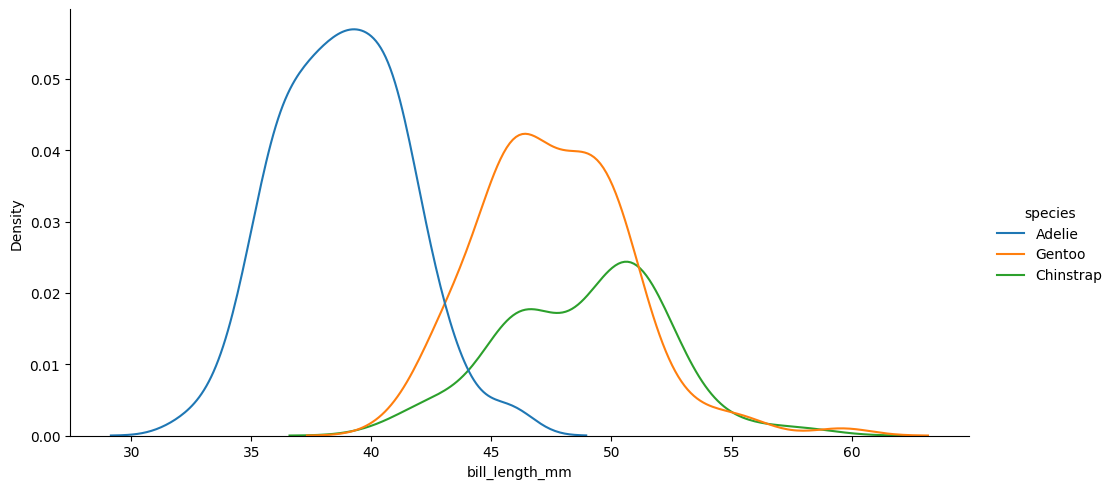

In [ ]:
# KDE plot of flipper length grouped by species
sns.displot(data=penguin_data, kind='kde', x='bill_length_mm', hue='species', aspect=2);

> Add code in the boxes below to create KDE plots for `bill_depth_mm`, `flipper_length_mm` and `body_mass_g` grouped by species.

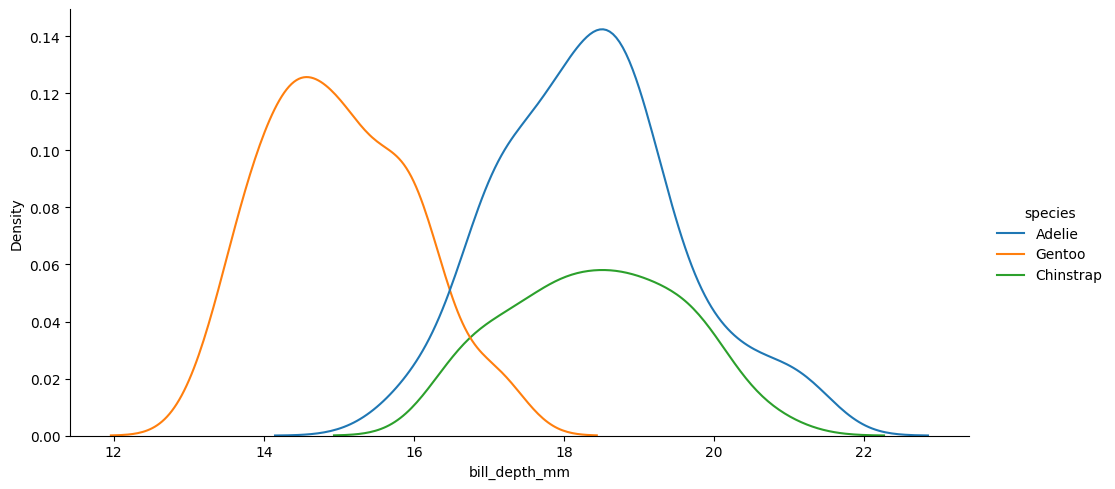

In [ ]:
# KDE plot of bill_depth_mm grouped by species
sns.displot(data=penguin_data, kind='kde', x='bill_depth_mm', hue='species', aspect=2);

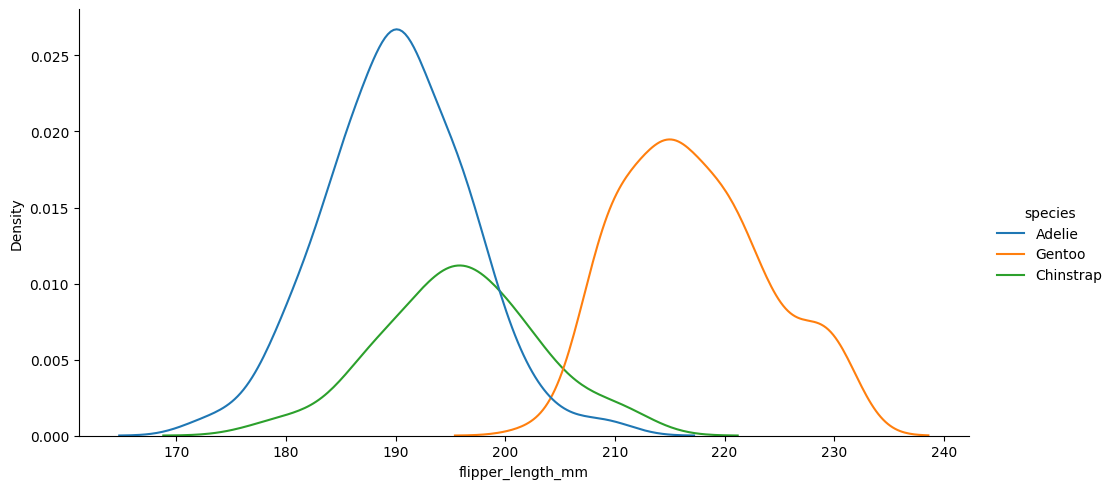

In [ ]:
# KDE plot of flipper_length_mm grouped by species
sns.displot(data=penguin_data, kind='kde', x='flipper_length_mm', hue='species', aspect=2);

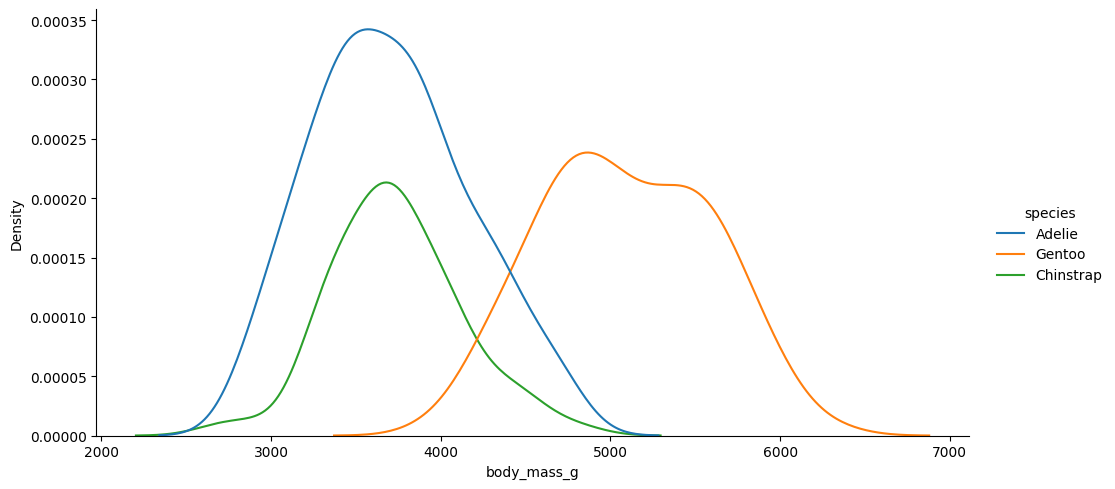

In [ ]:
# KDE plot of body_mass_g grouped by species
sns.displot(data=penguin_data, kind='kde', x='body_mass_g', hue='species', aspect=2);

## Checkpoint 1
> * Use your statistics and visualisations to describe the differences between the three species of penguin.
> * Explain which feature you think would be the most useful to distinguish a Gentoo penguin from the other two species.

 Adelie and chinstrap penguins seem to have similar densities for respective features execpt for bill length where adelie penguins clearly have a smaller bill length. Therefore it would be useful to use any of the other three fields to attempt to distinguish gentoo penguins, but perhaps flipper length is the best because there is the least overlap as seen in [22] with the other two types of penguins.

# Building models with a single input feature

In this activity you are going to generate some binary classification models. These will split the data into two groups depending on some of the values of the numerical features. For example, a simple model might be to classify penguins with bill lengths greater than 40mm as Gentoo penguins and those with bill lengths less than 40mm as not Gentoo penguins.

You will use an 75:25 training-testing split for your data as you saw in lesson 5. Your model will be built using 75% of the data and the remaining 25% will be used to measure how well the model perfoms on unseen data.

* To create a model you will send your training data to a machine learning algorithm, `DecisionTreeClassifier`, which will find the best split for your choice of input features.
* You will then measure your model by finding the *accuracy* using the testing data, i.e. the percentage of penguins it has correctly identified.

## Building a model based on bill length

The code for building and measuring a binary classification model has a very similar structure to the code you met for building a linear regression model in lesson 5. The main differences are that it will display the model using a *decision tree* and the model will be measured using *accuracy*, the percentage of items correctly identified when the model is applied to the testing data.

The code block builds and measures the model using three stages:
* Define the input features and the target feature. The input can be a single feature or a list of features. The target feature has the values 0 or 1. It then perform a training-testing split. This creates four objects: a training set of inputs and training list of outputs for building the model; a testing set of inputs and testing list of outputs for measuring the model.
* Find the best model for the given input features using the machine learning algorithm `DecisionTreeClassifier`. This model is displayed using a decision tree.
* Create a list of target predictions using the testing data inputs and compare these to the actual values in the testing target list. The percentage correct is given as the accuracy.

> Run the code in the box below to create a binary classification model using `bill_length` as the input.

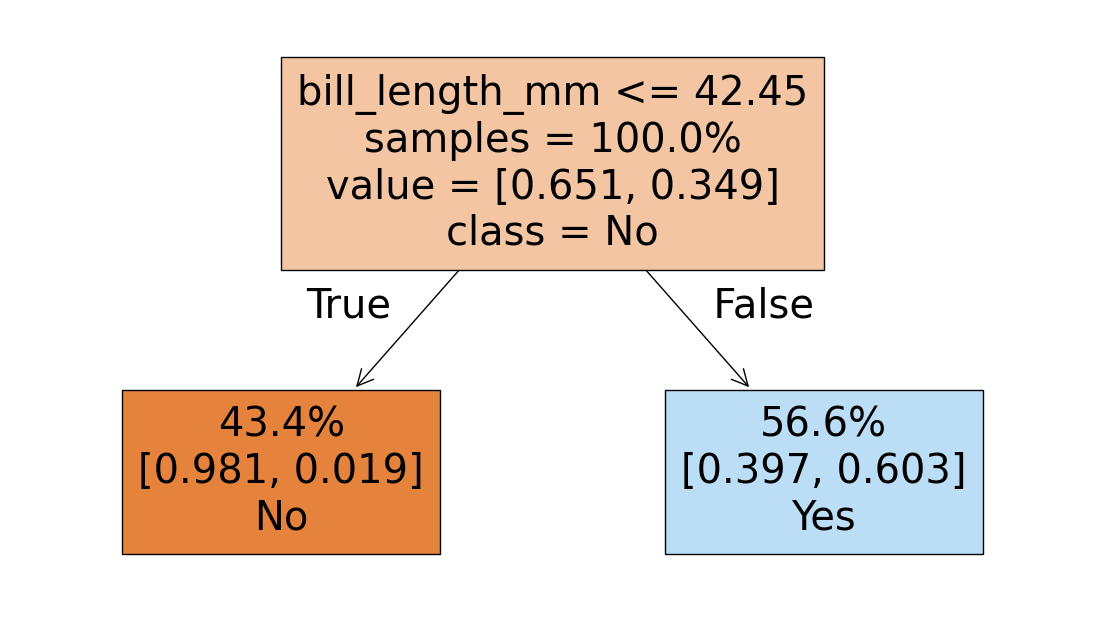

Accuracy:  72.6 %


In [ ]:
# define the input feature(s), output (or target) feature and perform the training-testing split
input_features = ['bill_length_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create and display the model
tree_model = DecisionTreeClassifier(max_depth=1).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions and calculate the accuracy by comparing with the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

## Interpretting decision trees

Decision trees are used to visualise binary classfication models. The top line of the first box, or *node*, tells you how to split the data: you follow the left arrow if this statement is true and the right arrow otherwise. The final line in the bottom row of boxes tells you whether the model has classified the groups as 1/Yes or 0/No.

The model shown here suggests that penguins with a bill length less than or equal to 42.45mm should be classified as not Gentoo and those with a bill length greater than 41.6mm should be classified as Gentoo. When this model is applied to the testing data it has accurately predicted whether 72.6% of the penguins are Gentoo or not. It has therefore misclassified 27.4% of penguins.

The *samples* and *value* lines in the boxes show what proportion of the testing data is being considered at each node and the fraction of these that are 0 or 1. This is useful information for more detailed analysis of decision trees but is beyond the scope of this course.

## Building models based on other features

> Add code to the boxes below to build models based on `bill_depth_mm`, `flipper_length_mm` and `body_mass_g`.

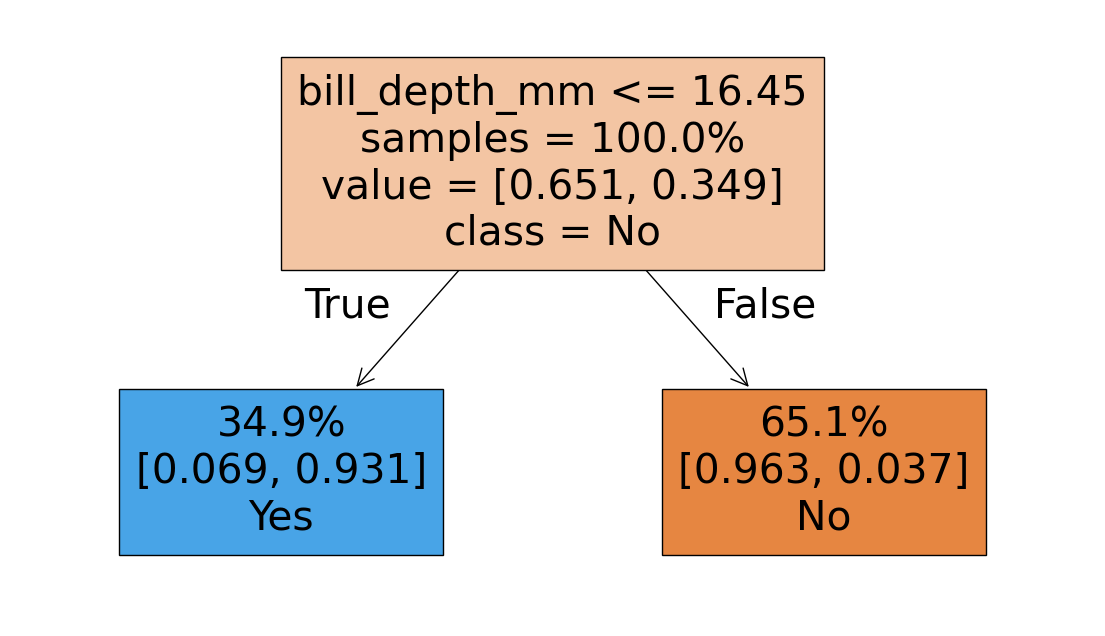

Accuracy:  96.4 %


In [ ]:
# Build a model based on bill depth

# define the input feature(s), output (or target) feature and perform the training-testing split
input_features = ['bill_depth_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create and display the model
tree_model = DecisionTreeClassifier(max_depth=1).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions and calculate the accuracy by comparing with the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

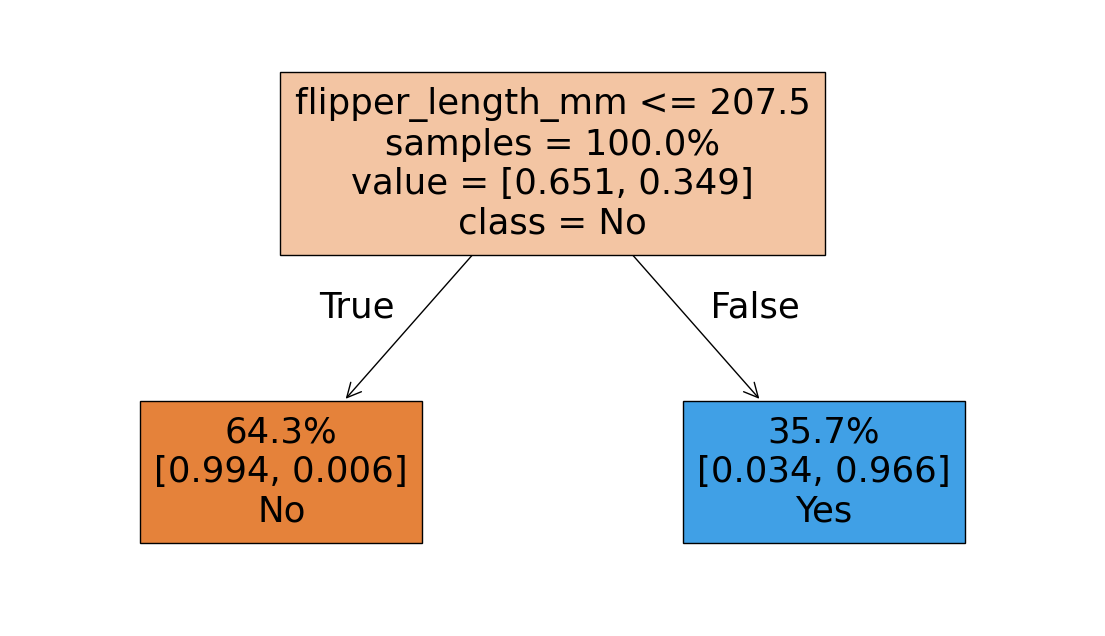

Accuracy:  95.2 %


In [ ]:
# Build a model based on flipper length

# define the input feature(s), output (or target) feature and perform the training-testing split
input_features = ['flipper_length_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create and display the model
tree_model = DecisionTreeClassifier(max_depth=1).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions and calculate the accuracy by comparing with the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

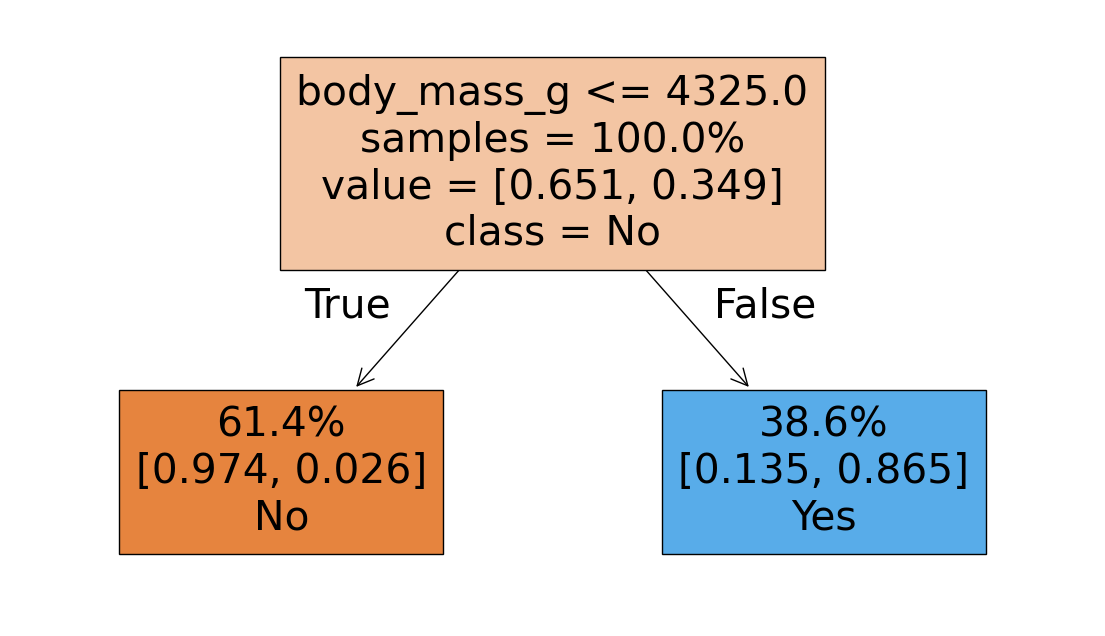

Accuracy:  88.1 %


In [ ]:
# Build a model based on body mass

# define the input feature(s), output (or target) feature and perform the training-testing split
input_features = ['body_mass_g']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create and display the model
tree_model = DecisionTreeClassifier(max_depth=1).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions and calculate the accuracy by comparing with the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

## Checkpoint 2

> * Which input feature gives the best model and which input feature gives the worst model?
> * Explain how this is consistent with your responses to Checkpoint 1.

# Building a model based on two input features

Just as you did with your regression models, you can give more than one input feature. You will need to increase the `max_depth` of your tree from 1 to 2 to allow for more decisions to be made.

> Run the code in the box below to create a model based on bill length and bill depth.

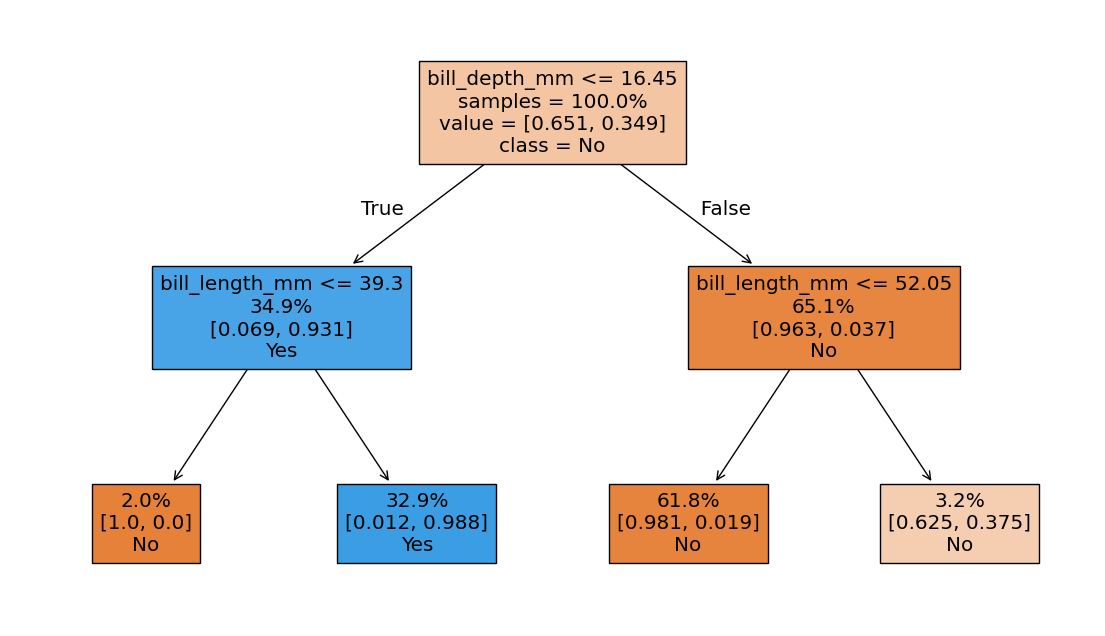

Accuracy:  (98, 1) %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['bill_length_mm', 'bill_depth_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred)),1),"%")

This model suggests that penguins with a bill depth less than or equal to 16.45mm and a bill length greater than 39.3mm are Gentoo; otherwise they are not Gentoo.

The second set of boxes gives a condition of `bill_length_mm <= 52.05` but suggests that the penguins are not Gentoo whether this condition is true or not. The machine learning algorithm has classified them into two groups, one of which it is confident about and the other it is not confident about. This is indicated by the shading in the boxes.

> In the code boxes below build some other models based on multiple input features.

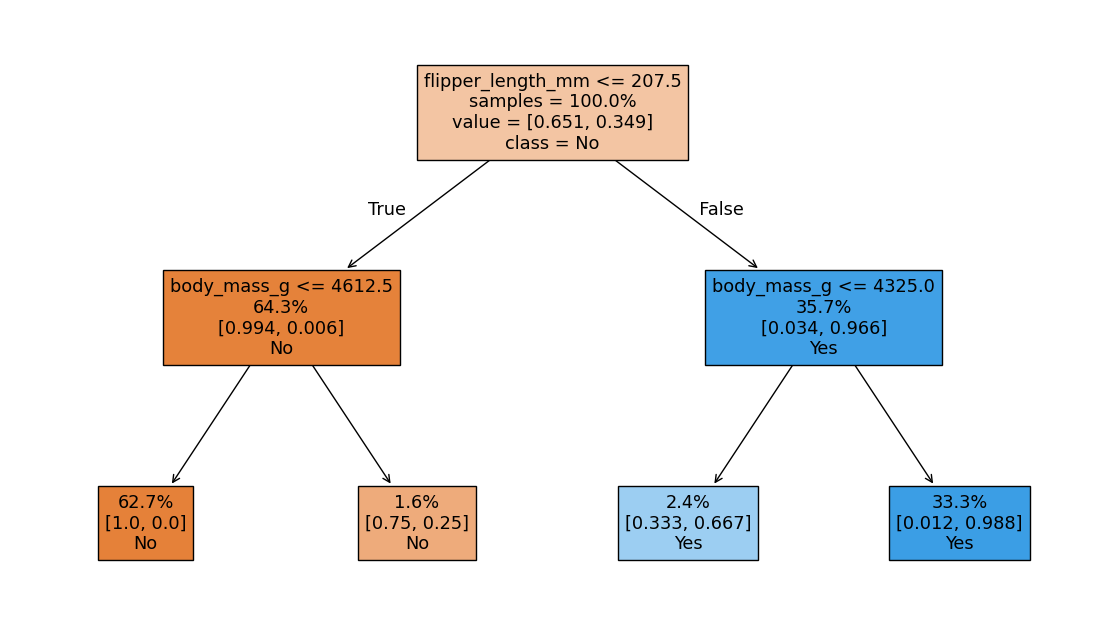

Accuracy:  95.2 %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['flipper_length_mm', 'body_mass_g']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

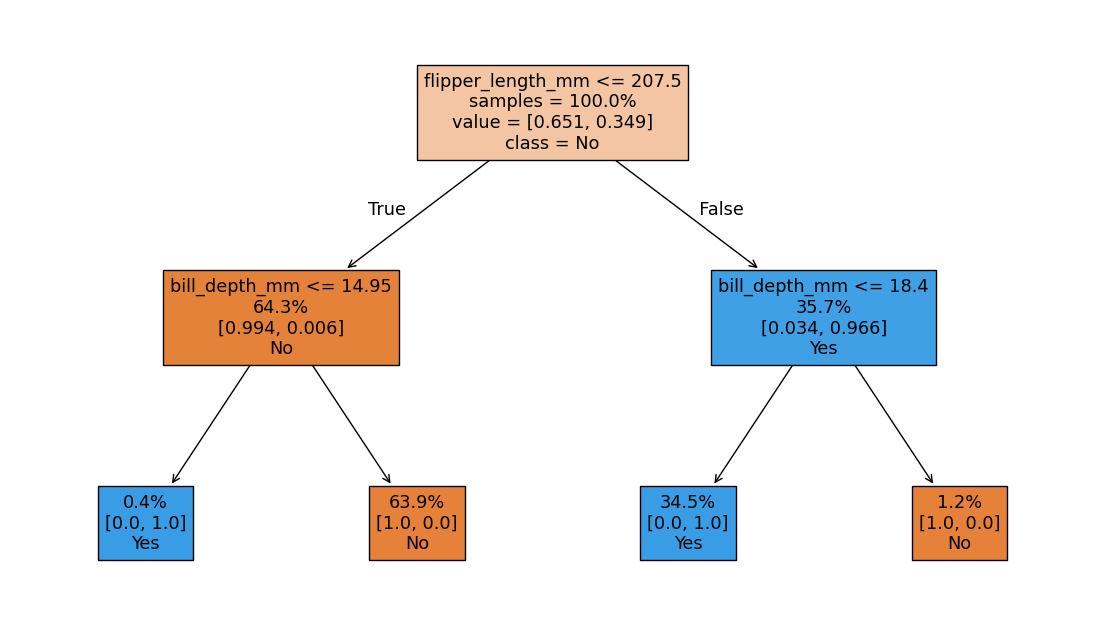

Accuracy:  98.8 %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['flipper_length_mm', 'bill_depth_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

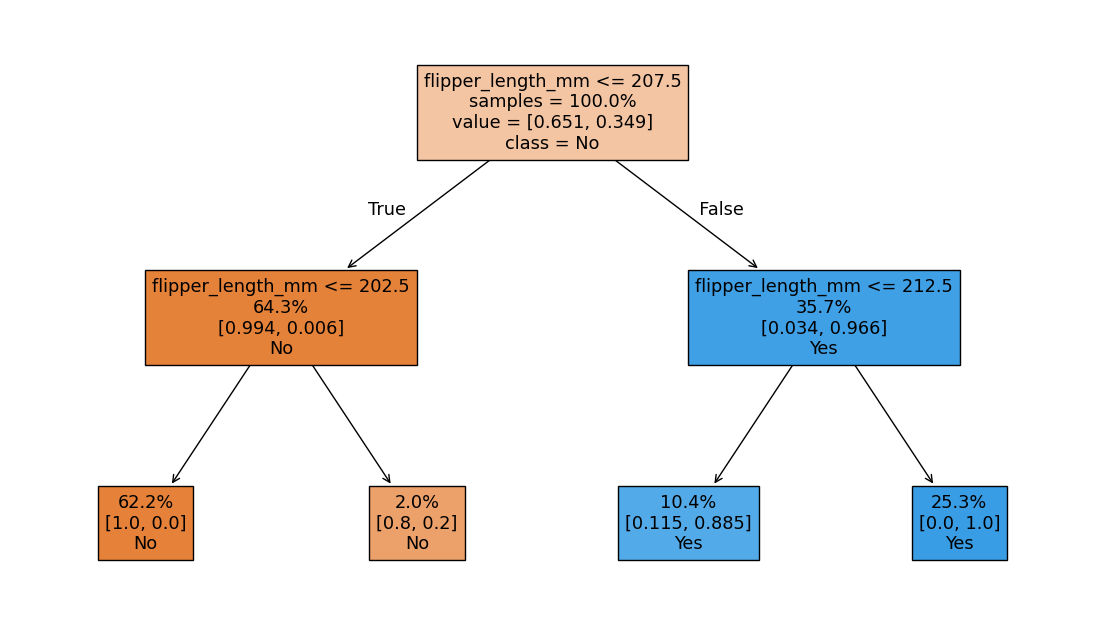

Accuracy:  95.2 %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['bill_length_mm', 'flipper_length_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

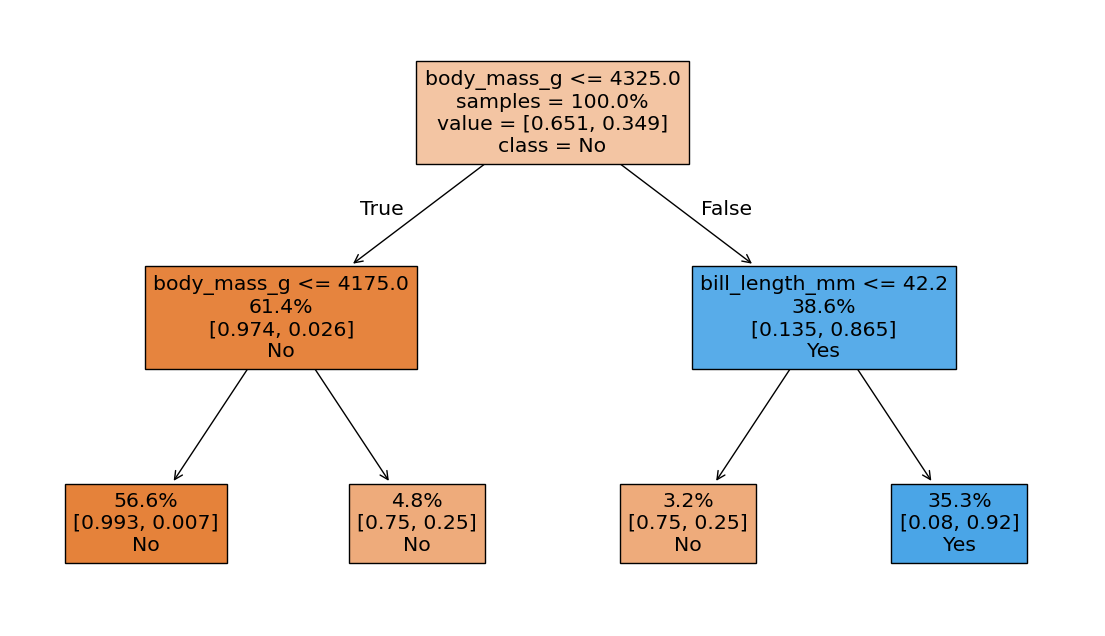

Accuracy:  92.9 %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['bill_length_mm', 'body_mass_g']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

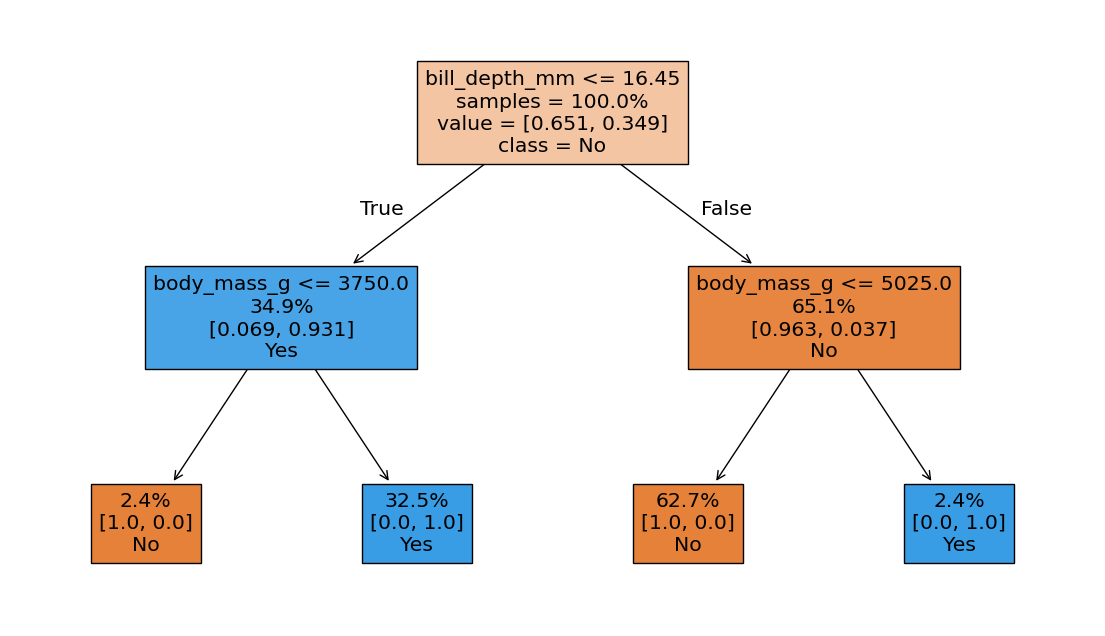

Accuracy:  100.0 %


In [ ]:
# define the input feature(s), output (or target) feature, perform the training-testing split
input_features = ['body_mass_g', 'bill_depth_mm']
input_data = penguin_data[input_features]
target_data = penguin_data['gentoo']

input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the and display the model
tree_model = DecisionTreeClassifier(max_depth=2).fit(input_train, target_train)
plot_decision_tree(tree_model)

# create a list of the predictions, display a two-way-table of predictions/actual values for the testing data, calculate the accuracy for the testing data
target_pred = tree_model.predict(input_test)
print("Accuracy: ",(round(100*accuracy_score(target_test, target_pred),1)),"%")

## Checkpoint 3

> * Which input features give the best model? How much better is this than the best model using a single input feature?
> * How well would you expect this model to perform if you applied it to a data set of penguins from a different set of islands in the Antartic?

having the input features of body mass and bill depth are most accurate at 100% accuracy, so it doesn't get better than this so it's worth using these two most of the time, but it should also be important to try not to over generalise. As for different islands in the Antarctic, different islands may have slightly different conditions to this one, and hence you wouldn't necesarily be able to use this field pairing, and it would likely be more accurate to do an analysis per island.